In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

import torch 
import torch.nn as nn
from torch.optim import Adam
from torch.distributions import Categorical

import gymnasium as gym 
import flappy_bird_gymnasium

In [85]:
env = gym.make("FlappyBird-v0", render_mode="rgb_array", use_lidar = False)

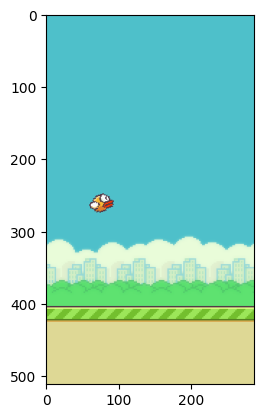

In [86]:
obs, _ = env.reset()
img = env.render()
plt.imshow(img)

In [21]:
env1 = gym.make("FlappyBird-v0", render_mode = "human", use_lidar = False)
obs,_ = env1.reset()
env1.render()
while True:
    next_state, reward, term, trunc, info = env1.step(env1.action_space.sample())
    if term or trunc:
        break

env1.close()


<module 'flappy_bird_gymnasium' from 'c:\\Users\\Ashutosh Thapa\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\flappy_bird_gymnasium\\__init__.py'>

In [27]:
print(env.action_space)
print(env.observation_space)


Discrete(2)
Box(-1.0, 1.0, (12,), float64)


In [87]:
class Actor(nn.Module):
    def __init__(self, n_states, n_actions):
        super(Actor,self).__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(n_states,128),
            nn.Tanh(),
            nn.Linear(128,64),
            nn.Tanh(),
            nn.Linear(64,n_actions),
            nn.Softmax(dim=-1)
        )


    def forward(self, x):
        return self.fc1(x)


class Critic(nn.Module):
    def __init__(self, n_states):
        super(Critic,self).__init__()

        self.fc2 = nn.Sequential(
            nn.Linear(n_states,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,1)
        )


    def forward(self, x):
        return self.fc2(x)



In [91]:

class RLAgent:
    def __init__(self,env, n_states, n_actions, n_episodes, gamma=0.99):
        self.env = env
        self.n_states = n_states
        self.n_actions = n_actions
        self.n_episodes = n_episodes

        self.gamma = gamma
        self.lr = 1e-3
        self.epsilon = 0.2
        self.k = 10
        self.rollout_steps = 2048
        self.entropy_coeff = 0.01


        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]
        self.dones = []

        self.rewards = []
        self.log_prob = []
        self.old_log_prob = []

        self.states = []
        self.actions = []
        self.Rewards = []

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.Actor = Actor(self.n_states,self.n_actions)
        self.Actor.to(self.device)
        self.Critic = Critic(self.n_states)
        self.Critic.to(self.device)
        #self.optim = Adam(
        #    list(self.Actor.parameters()) + list(self.Critic.parameters()),
        #    lr=self.lr)
        self.optim = Adam([
            {'params': self.Actor.parameters(), 'lr': 3e-4},
            {'params': self.Critic.parameters(), 'lr': 1e-3}])

        self.scheduler = torch.optim.lr_scheduler.LinearLR(
            self.optim, start_factor=1.0, end_factor=0.1, total_iters=n_episodes)




    def choose_action(self,state):
        state = torch.tensor(state,dtype=torch.float32).unsqueeze(0).to(self.device)
        # PYTORCH NETWORKS ALWAYS TAKE TENSORS ONLY AS INPUT
        action_prob = self.Actor(state)

        distr = Categorical(action_prob)
        action = distr.sample()
        log_prob = distr.log_prob(action)
        self.log_prob.append(log_prob)

        self.old_log_prob.append(log_prob.detach())  # Freezing old_log_prob

        return action.item()

 #GENERALIZED ADVANTAGE ESTIMATION (Instead of montecarlo return we use TD(lambda) return)
    def compute_gae(self, rewards, values, dones,last_state, lam=0.95):
        advantages = []
        gae = 0
        with torch.no_grad():
             last_state_t = torch.tensor(last_state, dtype=torch.float32).unsqueeze(0).to(self.device)
             next_value = self.Critic(last_state_t).squeeze().item() * (1 - dones[-1])
        values_ext = values + [next_value]

        for t in reversed(range(len(rewards))):
            delta = (rewards[t]
                     + self.gamma * values_ext[t+1] * (1 - dones[t])
                     - values_ext[t])
            gae = delta + self.gamma * lam * (1 - dones[t]) * gae
            advantages.insert(0, gae)

        advantages = torch.tensor(advantages, dtype=torch.float32)
        returns = advantages + torch.tensor(values, dtype=torch.float32)
        return advantages, returns


    def compute_loss(self,states,last_state,rewards,dones):


        states = torch.tensor(np.array(states), dtype=torch.float32).to(self.device)
        # PYTORCH NETWORKS ALWAYS TAKE TENSORS ONLY AS INPUT
        actions = torch.tensor(self.actions, dtype=torch.long).to(self.device)
        old_log_probs = torch.stack(self.old_log_prob).squeeze().to(self.device) # Before stack — list of tensors
                                                                #[tensor(1.38), tensor(1.25), tensor(1.41)]
                                                                # After stack — single tensor
                                                                #tensor([1.38, 1.25, 1.41])


        with torch.no_grad():  #computing advantage once outside epoch wala loop
            V = self.Critic(states).squeeze(-1).cpu().tolist() 
        
        A, returns = self.compute_gae(rewards, V, dones,last_state)
 
        G = returns.to(self.device)
        A = A.to(self.device)

        A_norm = ((A - A.mean()) / (A.std() + 1e-8)).to(self.device)

        batch_size = len(states)
        mini_batch_size = 64



        for _ in range(self.k):
            
            indices = np.random.permutation(batch_size) #scrambles array of num from 0 to 2047

            for start in range(0, batch_size, mini_batch_size):


                end = start + mini_batch_size
                mb_indices = indices[start:end]

                mb_states = states[mb_indices]
                mb_actions = actions[mb_indices]
                mb_old_log_probs = old_log_probs[mb_indices]
                mb_A_norm = A_norm[mb_indices]
                mb_G = G[mb_indices]


                action_probs = self.Actor(mb_states)
                dist = Categorical(action_probs)
                new_log_probs = dist.log_prob(mb_actions)
                entropy = dist.entropy().mean()

                new_V = self.Critic(mb_states).squeeze(-1)


                ratio = (new_log_probs - mb_old_log_probs).exp()

                clipped = torch.clamp(ratio, 1 - self.epsilon, 1 + self.epsilon)
                Actorloss = -torch.min(ratio * mb_A_norm.detach(), clipped * mb_A_norm.detach()).mean() # .detach() to prevent flow of grad through adv into critic twice
                                                                                        ## A->V-> critic weightd meaning actor loss le critic weights lai change garthiyo if there was no detach
                Criticloss = ((mb_G - new_V)**2).mean()    

                loss = Actorloss + 0.5 * Criticloss - self.entropy_coeff * entropy # - sign means we want to max entropy)

                self.optim.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.Actor.parameters()) + list(self.Critic.parameters()),
                    max_norm = 0.5
                )
                self.optim.step() 
        self.scheduler.step()                                               
        del self.log_prob[:]
        del self.old_log_prob[:]



    def train(self):
        
        for episode in range(self.n_episodes):
    
            self.states = []
            self.actions = []
            self.rewards = []
            self.log_prob = []
            self.old_log_prob = []
            self.dones = []
            
            steps_collected = 0

            while steps_collected < self.rollout_steps: #collecting 2048 trajectories
                state, _ = self.env.reset()
                done = False
                total_reward = 0



                while not done:
                    action = self.choose_action(state)
                    next_state, reward, term, trunc, _ = self.env.step(action)
                    done = term or trunc

                    self.states.append(state)
                    self.rewards.append(reward)
                    self.actions.append(action)
                    self.dones.append(1.0 if term else 0.0)


                    total_reward += reward

                    #last_state = state

                    state = next_state

                    steps_collected += 1

                    if steps_collected == self.rollout_steps:
                        break

                if done:
                    self.all_rewards.append(total_reward)
        
            self.compute_loss(self.states,state,self.rewards,self.dones)

            self.entropy_coeff = max(self.entropy_coeff * 0.999, 0.0001)

            
            if episode % 10 == 0:
                self.epino_forplot.append(episode)
            
                if len(self.all_rewards) > 0:
                    avg = np.mean(self.all_rewards[-10:]) 
                    last_completed = self.all_rewards[-1]
                else:
                    avg = 0
                    last_completed = 0
                    
                print(f"Update {episode} | Avg_Reward (last 10): {avg:.2f} | Last_Completed_Reward: {last_completed:.2f}")

                                    
    def plot(self):
        moving_avg = np.convolve(self.all_rewards, np.ones(100)/100, mode='valid')
        fig, ax = plt.subplots(figsize = (8,6))

        x_axis = np.arange(99, len(self.all_rewards)) # creates array from 99 to total episode length
        #ax.plot(self.epino_forplot,self.reward_per_10epi,color='blue',label="Reward Per 10 Episodes")
        ax.plot(x_axis, moving_avg, color='red', label="100-Episode Moving Average")

        #X = 0 on the graph technically represents Episode 100, X = 1 represents Episode 101, and so on.

        ax.set_xlabel("Steps")
        ax.set_ylabel("Reward")
        ax.set_title("PPO Training Progress")
        ax.legend(loc="upper left")
        plt.show()






        


In [92]:
Agent = RLAgent(env, 12, 2, 3000)

In [93]:
Agent.train()

Update 0 | Avg_Reward (last 10): -6.96 | Last_Completed_Reward: -8.10
Update 10 | Avg_Reward (last 10): 4.03 | Last_Completed_Reward: 3.90
Update 20 | Avg_Reward (last 10): 8.59 | Last_Completed_Reward: 4.20
Update 30 | Avg_Reward (last 10): 13.66 | Last_Completed_Reward: 4.10
Update 40 | Avg_Reward (last 10): 18.47 | Last_Completed_Reward: 8.50
Update 50 | Avg_Reward (last 10): 17.80 | Last_Completed_Reward: 8.40
Update 60 | Avg_Reward (last 10): 18.11 | Last_Completed_Reward: 25.30
Update 70 | Avg_Reward (last 10): 21.65 | Last_Completed_Reward: 34.70
Update 80 | Avg_Reward (last 10): 10.77 | Last_Completed_Reward: 8.40
Update 90 | Avg_Reward (last 10): 13.79 | Last_Completed_Reward: 8.40
Update 100 | Avg_Reward (last 10): 25.41 | Last_Completed_Reward: 92.40
Update 110 | Avg_Reward (last 10): 15.84 | Last_Completed_Reward: 22.60
Update 120 | Avg_Reward (last 10): 16.04 | Last_Completed_Reward: 18.80
Update 130 | Avg_Reward (last 10): 17.85 | Last_Completed_Reward: 22.40
Update 140 |

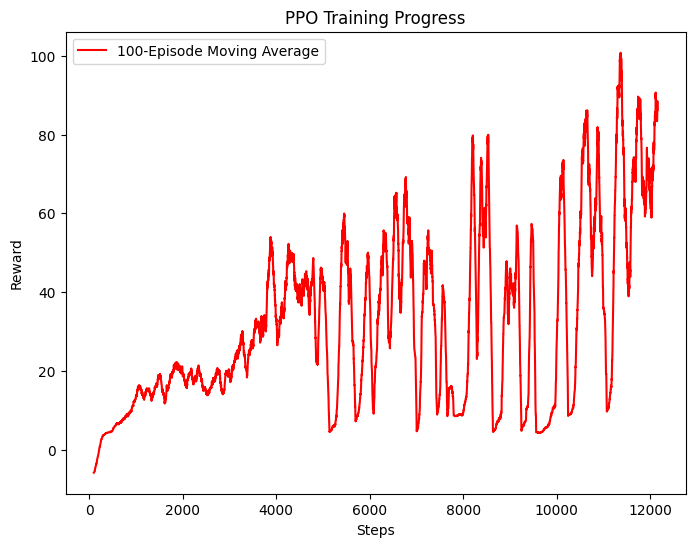

In [94]:
Agent.plot()

In [95]:
torch.save({
    'actor': Agent.Actor.state_dict(),
    'critic': Agent.Critic.state_dict(),
    'optimizer': Agent.optim.state_dict(),
}, 'Flappy_save.pth')

In [53]:
checkpoint = torch.load('Flappy_save.pth')
Agent.Actor.load_state_dict(checkpoint['actor'])
Agent.Critic.load_state_dict(checkpoint['critic'])
Agent.optim.load_state_dict(checkpoint['optimizer'])

Agent.Actor.eval()
Agent.Critic.eval()


Critic(
  (fc2): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [99]:
env = gym.make("FlappyBird-v0",render_mode='human', use_lidar = False)

for i in range(3):
    done = False
    total_reward = 0
    state,_ = env.reset()

    while not done:

        action = Agent.choose_action(state)
        next_state, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        state = next_state
        total_reward += reward

    print(f'Total Reward This Episode: {total_reward}')
env.close()


Total Reward This Episode: 232.3999999999929
Total Reward This Episode: 34.80000000000019
Total Reward This Episode: 379.8000000000141
